## Impacts of Domain weights using `LeNet` in Agriculture

This notebook explores the application of Deep Learning (DL) models-specifically the **LeNet architecture**-to investigate the impact of **pretrained (domain) weights** on model performance across different datasets.

### 🎯 Objective
The primary goal of this project is to evaluate how pretrained weights influence classification performance when transferring knowledge from one domain to another. To achieve this, we design and compare three models:

1. **Source Model (Pretraining Phase)**  
   - A LeNet model trained on a general image dataset to learn feature representations.  
   - The trained weights from this model will be saved for reuse.

2. **Target Model with Pretrained Weights (Transfer Learning)**  
   - A LeNet model initialized using the pretrained weights from the source model.  
   - Fine-tuned on a different dataset to evaluate knowledge transfer.

3. **Target Model without Pretrained Weights (Baseline)**  
   - A LeNet model trained from scratch on the same target dataset.  
   - Serves as a baseline for comparison.

---

### 🗂️ Datasets Used

#### 1. Source Dataset (Pretraining)
**Fruits and Vegetables Image Recognition Dataset**  
*Kaggle, 2020 - by Kritik Seth*

- Contains images of various fruits and vegetables for object recognition tasks.
- Categories include:
  - **Fruits:** Banana, Apple, Pear, Grapes, Orange, Kiwi, Watermelon, etc.
  - **Vegetables:** Carrot, Tomato, Potato, Onion, Spinach, Cabbage, etc.
- Dataset structure:
  - `Train`: 100 images per class  
  - `Validation`: 10 images per class  
  - `Test`: 10 images per class  

📌 *Purpose:*  
To train the initial LeNet model and extract generalized visual features.

---

#### 2. Target Dataset (Evaluation)
**Banalyzer – Banana Ripeness Classification Dataset**

- Classifies bananas into four ripeness stages:
  - Unripe  
  - Ripe  
  - Overripe  
  - Rotten  
- Includes:
  - Image dataset (train/test split)
  - Training and prediction scripts
  - Streamlit web interface for deployment

📌 *Purpose:*  
To evaluate how well pretrained features transfer to a more specific classification task.

---

### ⚙️ Experimental Setup

- All models use the **LeNet architecture** for consistency.
- Two training strategies are compared:
  - **With pretrained weights** (transfer learning)
  - **Without pretrained weights** (training from scratch)
- Performance will be evaluated using standard classification metrics such as:
  - Accuracy
  - Precision
  - Recall
  - F1-score

---

### 📊 Expected Outcome

This experiment aims to demonstrate:
- The effectiveness of **transfer learning** using pretrained weights.
- Whether features learned from a general dataset (fruits & vegetables) can improve performance on a **domain-specific task** (banana ripeness classification).
- The performance gap between pretrained and non-pretrained models.

---

### 📚 References

- Seth, K. (2020). *Fruits and Vegetables Image Recognition Dataset*. Kaggle.  
  https://www.kaggle.com/kritikseth/fruit-and-vegetable-image-recognition

- Charles C R (2025). *Banana Ripeness Classification*. Kaggle.  
  https://www.kaggle.com/datasets/iamchaarles/banalyzer-banana-ripeness-classification-dataset

In the following code cell we are going to import all the packages that we are going to use for the rest of this notebook.

In [1]:
import torch
import random
import os
import time
import torchvision
import copy
import json
from pigmenta import PALETTES
from uuid import uuid4
import shutil

import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from IPython.display import FileLink
from shutil import copyfile
from torch.nn import functional as F
from PIL import Image
from torchvision import datasets, transforms
from torch.utils import data
from PIL import Image
from sklearn.metrics import classification_report
from helperfns.tables import tabulate_data
from helperfns.visualization import plot_complicated_confusion_matrix, plot_simple_confusion_matrix
from helperfns.utils import hms_string

from helperfns import visualization
from torchvision import models
import matplotlib as mpl
import warnings

warnings.filterwarnings("ignore")
print("torch: ", torch.__version__)
print("numpy: ", np.__version__)
print("pandas: ", pd.__version__)

torch:  2.9.0+cu126
numpy:  2.3.3
pandas:  2.3.3


### Seed

In the following code cell we are going to define the `SEED` for all random operation for reproducivity of results in this notebook.

In [2]:
SEED = 17

random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True

### Device

In the following code cell we are going to create a variable `device` that will hold the value of the device that is available so that we can have access to the `GPU` if available.

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

### 🗂️ Datasets

This project utilizes two datasets sourced from Kaggle to investigate the impact of pretrained weights through transfer learning.

---

#### 1. Source Dataset (Pretraining Phase)

> **Fruits and Vegetables Image Recognition Dataset**  
> https://www.kaggle.com/kritikseth/fruit-and-vegetable-image-recognition

This dataset contains labeled images of various fruits and vegetables, organized into training, validation, and test sets. It will be used to train the initial **LeNet model**, allowing it to learn general visual features. The learned weights from this model will be saved and later reused in the transfer learning phase.

---

#### 2. Target Dataset (Evaluation Phase)

> **Banalyzer – Banana Ripeness Classification Dataset**  
> https://www.kaggle.com/datasets/iamchaarles/banalyzer-banana-ripeness-classification-dataset

This dataset focuses on classifying bananas into four ripeness stages: *Unripe, Ripe, Overripe,* and *Rotten*. It will be used to evaluate the effectiveness of transferring pretrained weights.

Two models will be trained on this dataset:
- One initialized with **pretrained weights** from the source model  
- One trained **from scratch** (baseline)

---

### ⚙️ Data Access

To ensure reproducibility and efficient data handling, both datasets will be downloaded programmatically using the **Kaggle API**. This approach enables seamless integration into the notebook workflow and simplifies dataset management.

In [4]:
with open("C:\\Users\\crisp\\Downloads\\kaggle.json", 'r') as reader:
  keys = json.loads(reader.read())
  os.environ['KAGGLE_USERNAME'] = keys['username']
  os.environ['KAGGLE_KEY'] = keys['key']

!kaggle datasets download iamchaarles/banalyzer-banana-ripeness-classification-dataset --unzip -q
!kaggle datasets download kritikseth/fruit-and-vegetable-image-recognition --unzip -q

Dataset URL: https://www.kaggle.com/datasets/iamchaarles/banalyzer-banana-ripeness-classification-dataset
License(s): MIT
Dataset URL: https://www.kaggle.com/datasets/kritikseth/fruit-and-vegetable-image-recognition
License(s): CC0-1.0


In the next code cell, we will **compute the number of samples in each class** for both the **training** , **validation** and **testing** sets of the *Fruits and Vegetables dataset*. 

This step is important for understanding the **class distribution** and detecting any potential **class imbalance**, which could negatively impact model training and performance.

In [5]:
fruits_train_samples = dict(
    zip(os.listdir('train'), [len(os.listdir(os.path.join('train', i))) for i in os.listdir('train')])
)
fruits_test_samples =  dict(
    zip(os.listdir('test'), [len(os.listdir(os.path.join('test', i))) for i in os.listdir('test')])
)
fruits_validation_samples =  dict(
    zip(os.listdir('validation'), [len(os.listdir(os.path.join('validation', i))) for i in os.listdir('validation')])
)
fruits_test_samples, fruits_train_samples, fruits_validation_samples

({'apple': 10,
  'banana': 9,
  'beetroot': 10,
  'bell pepper': 10,
  'cabbage': 10,
  'capsicum': 10,
  'carrot': 10,
  'cauliflower': 10,
  'chilli pepper': 10,
  'corn': 10,
  'cucumber': 10,
  'eggplant': 10,
  'garlic': 10,
  'ginger': 10,
  'grapes': 10,
  'jalepeno': 10,
  'kiwi': 10,
  'lemon': 10,
  'lettuce': 10,
  'mango': 10,
  'onion': 10,
  'orange': 10,
  'paprika': 10,
  'pear': 10,
  'peas': 10,
  'pineapple': 10,
  'pomegranate': 10,
  'potato': 10,
  'raddish': 10,
  'soy beans': 10,
  'spinach': 10,
  'sweetcorn': 10,
  'sweetpotato': 10,
  'tomato': 10,
  'turnip': 10,
  'watermelon': 10},
 {'apple': 68,
  'banana': 75,
  'beetroot': 88,
  'bell pepper': 90,
  'cabbage': 92,
  'capsicum': 89,
  'carrot': 82,
  'cauliflower': 79,
  'chilli pepper': 87,
  'corn': 87,
  'cucumber': 94,
  'eggplant': 84,
  'garlic': 92,
  'ginger': 68,
  'grapes': 100,
  'jalepeno': 88,
  'kiwi': 88,
  'lemon': 82,
  'lettuce': 97,
  'mango': 86,
  'onion': 94,
  'orange': 69,
  'papr

In the next code cell, we will **compute the number of samples in each class** for both the **training** and **testing** sets of the *Banana Ripeness Classification dataset*.  

This step helps us understand the distribution of samples across the four ripeness stages-**Unripe, Ripe, Overripe, and Rotten**-and identify any potential **class imbalance** that may affect model performance.

In [6]:
banana_train_samples = dict(
    zip(os.listdir('banana_data/data/train'), [len(os.listdir(os.path.join('banana_data/data/train', i))) 
                                               for i in os.listdir('banana_data/data/train')])
)
banana_test_samples =  dict(
    zip(os.listdir('banana_data/data/test'), [len(os.listdir(os.path.join('banana_data/data/test', i))) for i in os.listdir('banana_data/data/test')])
)
banana_test_samples, banana_train_samples

({'overripe': 50, 'ripe': 50, 'rotten': 50, 'unripe': 50},
 {'overripe': 250, 'ripe': 250, 'rotten': 250, 'unripe': 250})

In the following code cell, we will **visualize the class distribution** of the *Banana Ripeness dataset* using a **pie chart**.  

This visualization provides an intuitive view of the **proportion of samples** across the four classes—**Unripe, Ripe, Overripe, and Rotten**—making it easier to identify any potential **class imbalance** in the dataset.

<Figure size 300x300 with 0 Axes>

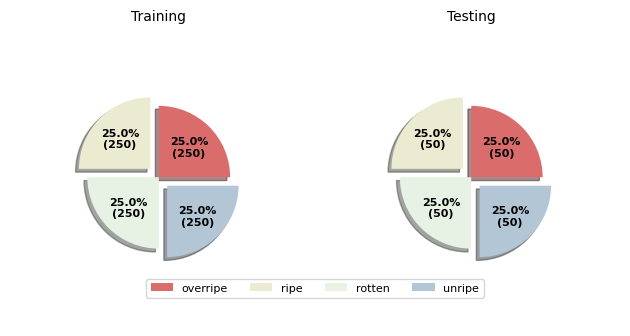

In [7]:
plt.figure(figsize=(3, 3))

def fmt(x, total):
    return '{:.1f}%\n({:.0f})'.format(x, total*x/100)

fig, axes = plt.subplots(1, 2)
wedges1, _, _ = axes[0].pie(
    banana_train_samples.values(),
    labels=None, 
    autopct= lambda x:fmt(x,sum(banana_train_samples.values())),
    textprops={'color': 'black', 'fontsize': 8, 'weight': 'bold'},
    colors=PALETTES.christmas[10:],
    radius=.6,
    explode=[.0, .1, .0, .1],
    pctdistance=0.6, 
    shadow=True,
)
axes[0].set_title("Training", fontsize=10)

wedges2, _, _ = axes[1].pie(
    banana_test_samples.values(),
    labels=None,
    autopct= lambda x: fmt(x, sum(banana_test_samples.values())),
    textprops={'color': 'black', 'fontsize': 8, 'weight': 'bold'},
    colors=PALETTES.christmas[10:],
    radius=.6,
    explode= [.0, .1, .0, .1],
    pctdistance=0.6, 
    shadow=True,
)
axes[1].set_title("Testing", fontsize=10)

fig.legend(
    wedges1,
    banana_train_samples.keys(),
    loc="upper center",
    bbox_to_anchor=(0.5, .30),
    ncol=4,
    fontsize=8
)
plt.tight_layout()
plt.show()



### 📊 Channel Means and Standard Deviations

In the next code cell, we will **compute the mean and standard deviation for each color channel (RGB)** across all images in the datasets.  

These statistics are crucial for **image normalization**, a preprocessing step that helps stabilize training, improve convergence speed, and enhance overall model performance.

We will perform this computation for **both the source dataset (Fruits and Vegetables)** and the **target dataset (Banana Ripeness)** to ensure consistent and dataset-specific normalization.

In [8]:
fruits_train_data = datasets.ImageFolder(
    root='train',
    transform= transforms.Compose([
        transforms.Resize((96, 96)),
        transforms.ToTensor()
      ])
    )

banana_train_data = datasets.ImageFolder(
    root='banana_data/data/train',
    transform= transforms.Compose([
        transforms.Resize((96, 96)),
        transforms.ToTensor()
      ])
)

fruits_means = torch.zeros(3)
fruits_stds = torch.zeros(3)

banana_means = torch.zeros(3)
banana_stds = torch.zeros(3)

for img, label in fruits_train_data:
  fruits_means += torch.mean(img, dim = (1,2))
  fruits_stds += torch.std(img, dim = (1,2))

for img, label in banana_train_data:
  banana_means += torch.mean(img, dim = (1,2))
  banana_stds += torch.std(img, dim = (1,2))
    
fruits_means /= len(fruits_train_data)
fruits_stds /= len(fruits_train_data)

banana_means /= len(banana_train_data)
banana_stds /= len(banana_train_data)

print(f'Fruits: Calculated means: {fruits_means}')
print(f'Fruits: Calculated stds: {fruits_stds}')
print()
print(f'Banana: Calculated means: {banana_means}')
print(f'Banana: Calculated stds: {banana_stds}')


Fruits: Calculated means: tensor([0.6289, 0.5808, 0.4279])
Fruits: Calculated stds: tensor([0.2153, 0.2228, 0.2498])

Banana: Calculated means: tensor([0.6267, 0.6098, 0.4972])
Banana: Calculated stds: tensor([0.2086, 0.2079, 0.2611])


From the computed channel means and standard deviations, we will **average them to obtain a single value**. This value will be used to **normalize all images**. Additionally, the images will be **resized to 96×96 pixels** and **converted to grayscale**. For the training set, we will also apply **data augmentation** to improve model generalization.  

The transformations for each dataset split are as follows:

```python
"train": transforms.Compose([
    transforms.Resize([96, 96]),
    transforms.RandomRotation(5),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomCrop(96, padding=2),
    transforms.ToTensor(),
    transforms.Grayscale(num_output_channels=1),
    transforms.Normalize(mean=[mean], std=[std], inplace=False)
]),
"valid": transforms.Compose([
    transforms.Resize([96, 96]),
    transforms.ToTensor(),
    transforms.Grayscale(num_output_channels=1),
    transforms.Normalize(mean=[mean], std=[std], inplace=False)
]),
"test": transforms.Compose([
    transforms.Resize([96, 96]),
    transforms.ToTensor(),
    transforms.Grayscale(num_output_channels=1),
    transforms.Normalize(mean=[mean], std=[std], inplace=False)
])
```


These transformations ensure that the data is standardized, and the training set benefits from random augmentations to make the model more robust.

In [9]:
banana_mean = banana_means.mean().item()
banana_std = banana_stds.mean().item()

fruits_mean = fruits_means.mean().item()
fruits_std = fruits_stds.mean().item()


print(f"Banana Mean: {banana_mean}")
print(f"Banana Std: {banana_std}")
print()
print(f"Banana Mean: {fruits_mean}")
print(f"Banana Std: {fruits_std}")


banana_image_transforms = {
    "train": transforms.Compose([
       transforms.Resize([96,96]),
       transforms.RandomRotation(5),
       transforms.RandomHorizontalFlip(.5),
       transforms.RandomCrop(96, padding=2),
       transforms.ToTensor(),
       transforms.Grayscale(
         num_output_channels =1
       ),
       transforms.Normalize(mean=[banana_mean], std=[banana_std], inplace=False)                         
    ]),
    "valid": transforms.Compose([
        transforms.Resize([96,96]),
        transforms.ToTensor(),
        transforms.Grayscale(
         num_output_channels=1
       ),
        transforms.Normalize(mean=[banana_mean], std=[banana_std], inplace=False)
    ]),
    "test": transforms.Compose([
        transforms.Resize([96,96]),
        transforms.ToTensor(),
        transforms.Grayscale(
         num_output_channels =1
       ),
        transforms.Normalize(mean=[banana_mean], std=[banana_std], inplace=False)
    ])
}


fruits_image_transforms = {
    "train": transforms.Compose([
       transforms.Resize([96,96]),
       transforms.RandomRotation(5),
       transforms.RandomHorizontalFlip(.5),
       transforms.RandomCrop(96, padding=2),
       transforms.ToTensor(),
       transforms.Grayscale(
         num_output_channels =1
       ),
       transforms.Normalize(mean=[fruits_mean], std=[fruits_std], inplace=False)                         
    ]),
    "valid": transforms.Compose([
        transforms.Resize([96,96]),
        transforms.ToTensor(),
        transforms.Grayscale(
         num_output_channels=1
       ),
        transforms.Normalize(mean=[fruits_mean], std=[fruits_std], inplace=False)
    ]),
    "test": transforms.Compose([
        transforms.Resize([96,96]),
        transforms.ToTensor(),
        transforms.Grayscale(
         num_output_channels =1
       ),
        transforms.Normalize(mean=[fruits_mean], std=[fruits_std], inplace=False)
    ])
}

Banana Mean: 0.5779144167900085
Banana Std: 0.22586625814437866

Banana Mean: 0.5458577275276184
Banana Std: 0.22929497063159943


In the following code cell, we will create datasets using the `ImageFolder` class from PyTorch. This utility **automatically maps each class label to its corresponding images** based on the directory structure, simplifying data loading and management.

We will apply this approach to **each dataset**, preparing both the **training** and **testing** sets for efficient model training and evaluation.

In [10]:
fruits_train_dataset = datasets.ImageFolder('train', transform = fruits_image_transforms['train'])
fruits_test_dataset = datasets.ImageFolder('test', transform = fruits_image_transforms['test'])
fruits_valid_dataset = datasets.ImageFolder('validation', transform = fruits_image_transforms['valid'])


banana_train_dataset = datasets.ImageFolder('banana_data/data/train', transform = banana_image_transforms['train'])
banana_test_dataset = datasets.ImageFolder('banana_data/data/test', transform = banana_image_transforms['test'])
fruits_class_names = fruits_train_dataset.classes
banana_class_names = banana_train_dataset.classes

### 📊 Validation Split

Next, we will **reserve 10% of the training data** from the *Banana Ripeness dataset* to create a **validation set**.  

Since this dataset does not include a predefined validation split, this step ensures that we have a separate subset of data to **monitor model performance during training**. It also helps in **detecting overfitting** and tuning hyperparameters more effectively.

In [11]:
VALID_RATIO = 0.2
# Split the training data into train + validation
n_valid_examples = int(len(banana_test_dataset) * VALID_RATIO)
n_train_examples = len(banana_test_dataset) - n_valid_examples
banana_train_dataset, banana_valid_dataset = data.random_split(banana_test_dataset,
                                           [n_train_examples, n_valid_examples])


> **Note:** After reserving the validation set from the training data, the resulting subsets still inherit the **training transforms** by default. To apply the correct transformations for each split, we will **create copies of the subsets** and **override their transforms** with the appropriate transformations for  **validation** datasets


In [12]:
banana_valid_dataset = copy.deepcopy(banana_valid_dataset)
banana_valid_dataset.dataset.transform = banana_image_transforms['valid']

In the following code cell we are going to use the pie chat to visualize the examples that we have in each subset.

<Figure size 300x300 with 0 Axes>

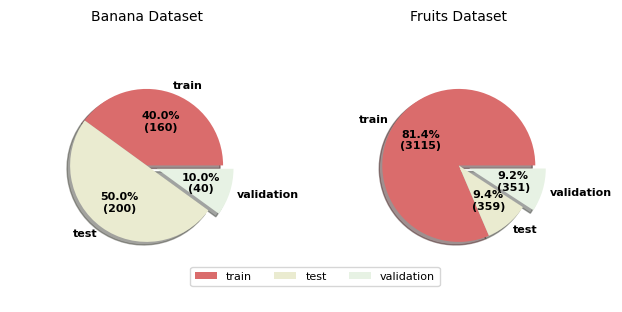

In [13]:
plt.figure(figsize=(3, 3))

fig, axes = plt.subplots(1, 2)
wedges1, _, _ = axes[0].pie(
    [len(banana_train_dataset), len(banana_test_dataset), len(banana_valid_dataset)], explode= [.0, .0, .1],
    labels=['train', 'test', 'validation'],
    autopct= lambda x:fmt(x,sum([len(banana_train_dataset), len(banana_test_dataset), len(banana_valid_dataset)])),
    textprops={'color': 'black', 'fontsize': 8, 'weight': 'bold'},
    colors=PALETTES.christmas[10:],
    radius=.7,
    pctdistance=0.6, 
    shadow=True,
)
axes[0].set_title("Banana Dataset", fontsize=10)

wedges2, _, _ = axes[1].pie(
    [len(fruits_train_dataset), len(fruits_test_dataset), len(fruits_valid_dataset)], explode= [.0, .0, .1],
    labels=['train', 'test', 'validation'],
    autopct= lambda x: fmt(x, sum([len(fruits_train_dataset), len(fruits_test_dataset), len(fruits_valid_dataset)])),
    textprops={'color': 'black', 'fontsize': 8, 'weight': 'bold'},
    colors=PALETTES.christmas[10:],
    radius=.7,
    pctdistance=0.6, 
    shadow=True,
)
axes[1].set_title("Fruits Dataset", fontsize=10)

fig.legend(
    wedges1,
    ['train', 'test', 'validation'],
    loc="upper center",
    bbox_to_anchor=(0.5, .30),
    ncol=4,
    fontsize=8
)
plt.tight_layout()
plt.show()

### 🔁 Data Loaders (Iterators)

Next, we will create **data loaders (iterators)** for both datasets to efficiently feed data into the models during training and evaluation.

We will use different batch sizes for each dataset:
- **Fruits and Vegetables dataset:** batch size of `64` (larger dataset, supports bigger batches)
- **Banana Ripeness dataset:** batch size of `16` (smaller dataset, helps improve generalization and stability)

This setup ensures efficient training while accommodating the size and characteristics of each dataset.

In [14]:
FRUITS_BATCH_SIZE,  BANANA_BATCH_SIZE = 64, 16
fruits_train_iterator = data.DataLoader(
    fruits_train_dataset, shuffle=True, batch_size= FRUITS_BATCH_SIZE
)
fruits_valid_iterator = data.DataLoader(
    fruits_valid_dataset, batch_size= FRUITS_BATCH_SIZE
)
fruits_test_iterator = data.DataLoader(
    fruits_test_dataset,  batch_size= FRUITS_BATCH_SIZE
)


banana_train_iterator = data.DataLoader(
    banana_train_dataset, shuffle=True, batch_size= BANANA_BATCH_SIZE
)
banana_valid_iterator = data.DataLoader(
    banana_valid_dataset, batch_size= BANANA_BATCH_SIZE
)
banana_test_iterator = data.DataLoader(
    banana_test_dataset,  batch_size= BANANA_BATCH_SIZE
)

### 🖼️ Visualizing Images

In this section, we will **visualize sample images from each dataset** along with their corresponding labels.  

This step helps us verify that the data has been **loaded and preprocessed correctly**, and provides a better understanding of the **visual characteristics** of each class.

In [15]:
def normalize_image(image):
  image_min = image.min()
  image_max = image.max()
  image.clamp_(min = image_min, max = image_max)
  image.add_(-image_min).div_(image_max - image_min + 1e-5)
  return image

Next we are going to define the `plot_images` function which is responsible for plotting images.

In [16]:
def plot_images(images, labels, class_names, normalize = True):
  n_images = len(images)
  rows = int(np.sqrt(n_images))
  cols = int(np.sqrt(n_images))
  fig = plt.figure(figsize = (10, 10))
  for i in range(rows*cols):
    ax = fig.add_subplot(rows, cols, i+1)
    image = images[i]
    if normalize:
        image = normalize_image(image)

    ax.imshow(image.permute(1, 2, 0).cpu().numpy(), cmap='gray')
    ax.set_title(class_names[labels[i]], fontsize=8, color='k')
    ax.axis('off')


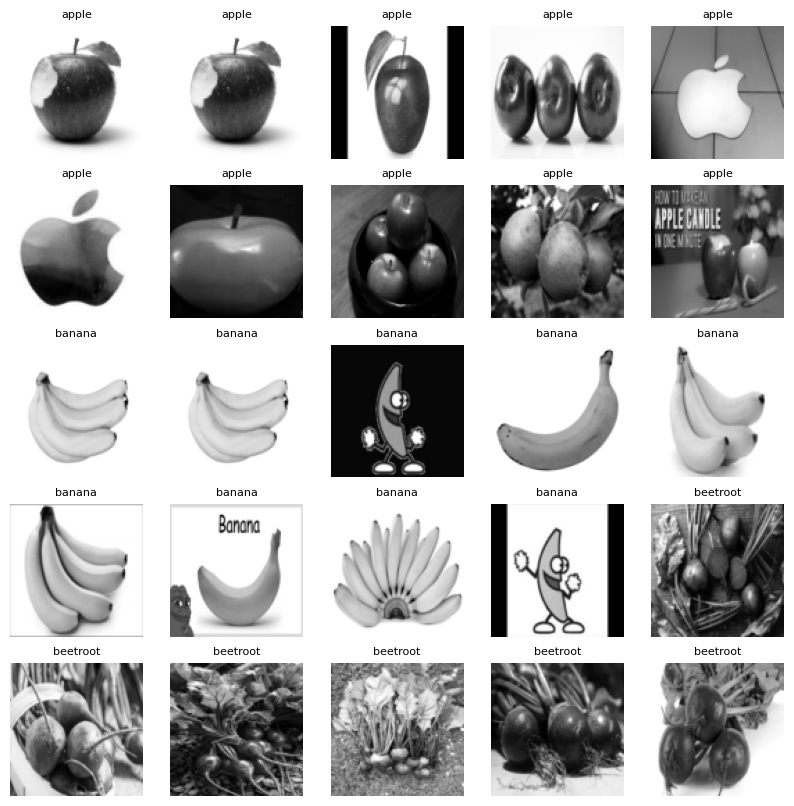

In [17]:
N_IMAGES = 25
labeled_data = next(iter(fruits_test_iterator))
images, labels = labeled_data[0][:N_IMAGES], labeled_data[1][:N_IMAGES]
plot_images(images, labels, fruits_class_names)

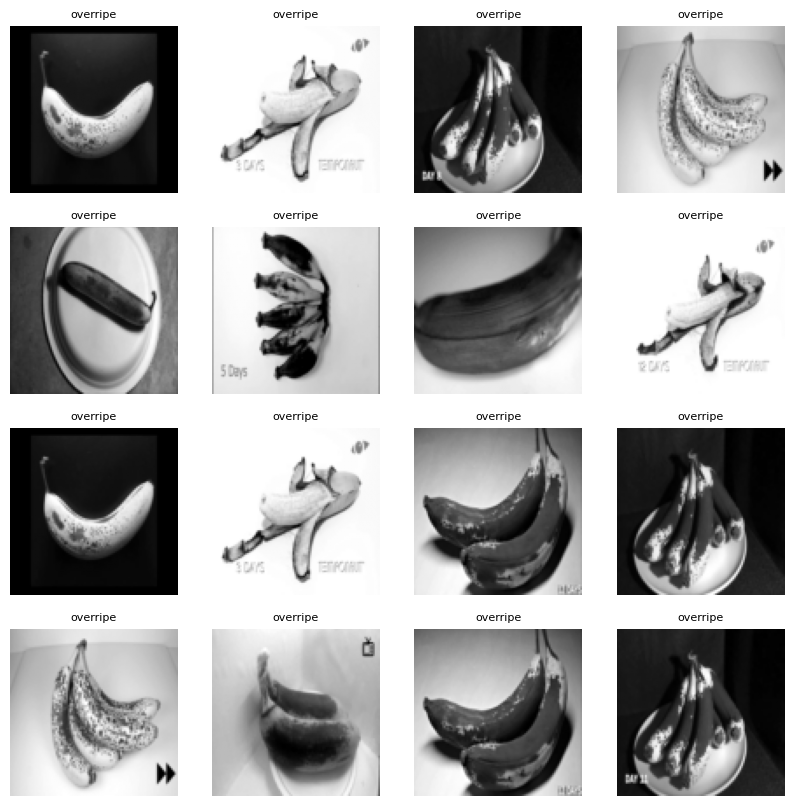

In [18]:
labeled_data = next(iter(banana_test_iterator))
images, labels = labeled_data[0][:N_IMAGES], labeled_data[1][:N_IMAGES]
plot_images(images, labels, banana_class_names)

### LeNet

In the following code cell, we will **define a LeNet model**. Unlike a standard MLP, LeNet is a **convolutional neural network (CNN)** that extracts spatial features from images, making it well-suited for image classification tasks like fruits classification. This model serves as a **lightweight yet effective baseline** for comparing performance against the MLP.


In [19]:
class LeNet(nn.Module):
    def __init__(self, output_dim, input_size=96):
        super(LeNet, self).__init__()
        self.convs = nn.Sequential(
            nn.Conv2d(1, 6, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool2d(2),                 
            nn.Conv2d(6, 16, kernel_size=5),  
            nn.ReLU(),
            nn.MaxPool2d(2)                 
        )
        
        with torch.no_grad():
            dummy = torch.zeros(1, 1, input_size, input_size)
            dummy = self.convs(dummy)
            self.flatten_dim = dummy.view(1, -1).shape[1]
        self.classifier = nn.Sequential(
            nn.Linear(self.flatten_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, output_dim)
        )

    def forward(self, x):
        x = self.convs(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

### 🧠 Model Initialization (LeNet)
In the following code cell, we will **create instances of the `LeNet` model**, initializing the convolutional neural network with the defined architecture for training and evaluation.

We will instantiate **three separate models** for our experimental setup:

1. **Source Model (Pretraining)**  
   - Trained on the *Fruits and Vegetables dataset*  
   - Used to learn general visual features and **save pretrained weights**

2. **Target Model with Pretrained Weights**  
   - Initialized using the saved weights from the source model  
   - Fine-tuned on the *Banana Ripeness dataset*

3. **Target Model without Pretrained Weights (Baseline)**  
   - Trained from scratch on the *Banana Ripeness dataset*  
   - Used for comparison to evaluate the impact of transfer learning

In [20]:
FRUITS_OUTPUT_DIM = 1 if len(fruits_class_names) == 2 else len(fruits_class_names)
BANANA_OUTPUT_DIM = 1 if len(banana_class_names) == 2 else len(banana_class_names)

fruits_lenet = LeNet(FRUITS_OUTPUT_DIM).to(device)
baseline_banana_lenet = LeNet(FRUITS_OUTPUT_DIM).to(device)
weighted_banana_lenet = LeNet(FRUITS_OUTPUT_DIM).to(device)

Next we are going to create a function that will count the model parameters.

In [21]:
def count_params(model):
  total_params = sum([p.numel() for p in model.parameters()])
  trainable_params = sum([p.numel() for p in model.parameters() if p.requires_grad])
  return f'{total_params:,}', f'{trainable_params:,}', f'{total_params - trainable_params:,}'

Then we will visualize the model parameters using a table.

In [22]:
tabulate_data(
    ["NAME", "TOTAL PARAMETERS", "TRAINABLE PARAMETERS", "NON-TRAINABLE PARAMETERS"],
    [
      ['fruits', *count_params(fruits_lenet)],
      ['baseline', *count_params(baseline_banana_lenet)], 
      ['weighted', *count_params(weighted_banana_lenet)], 
    ],
    "MODELS' PARAMETERS"
)


MODELS' PARAMETERS
+----------+------------------+----------------------+--------------------------+
| NAME     | TOTAL PARAMETERS | TRAINABLE PARAMETERS | NON-TRAINABLE PARAMETERS |
+----------+------------------+----------------------+--------------------------+
| fruits   |          916,464 |              916,464 |                        0 |
| baseline |          916,464 |              916,464 |                        0 |
| weighted |          916,464 |              916,464 |                        0 |
+----------+------------------+----------------------+--------------------------+


### ⚙️ Criterion and Optimizer

Next, we will define the **loss function** and **optimizer** for training our models.  

We will use **CrossEntropyLoss**, which is well-suited for **multi-class classification tasks** such as fruit classification and banana ripeness prediction.  

For optimization, we will use the **Adam optimizer** with default parameters, as it provides efficient and adaptive gradient-based learning.

This setup will be applied consistently across all models to ensure a fair comparison between the **baseline** and **pretrained (transfer learning)** approaches.

In [23]:
optimizers = {
    'fruits': torch.optim.Adam(fruits_lenet.parameters()),
    'baseline': torch.optim.Adam(baseline_banana_lenet.parameters()),
    'weighted': torch.optim.Adam(weighted_banana_lenet.parameters()),
}
criterions = {
    'weighted': nn.CrossEntropyLoss().to(device),
    'baseline': nn.CrossEntropyLoss().to(device),
    'fruits': nn.CrossEntropyLoss().to(device),
}

In the following code cell, we will define the `categorical_accuracy` function. This function **calculates the accuracy** of the model by comparing the predicted class labels with the true labels, providing a clear metric for evaluating model performance on classification tasks.

In [24]:
def categorical_accuracy(y_pred, y):
  top_pred = y_pred.argmax(1, keepdim=True)
  correct = top_pred.eq(y.view_as(top_pred)).sum()
  acc = correct.float()/ y.shape[0]
  return acc

### Train and Evaluate Functions

In the following code cell we are going to define the `train` and `evaluate` fuctions.

In [25]:
def train(model, iterator, optimizer, criterion, device):
  epoch_loss, epoch_acc = 0, 0
  model.train()
  for (x, y) in iterator:
    # features and labels to the device
    x = x.to(device)
    y = y.to(device).long()
    # Zero the gradients
    optimizer.zero_grad()
    y_pred = model(x)
    # Calculate the loss and accuracy
    y_pred = y_pred.squeeze()

    loss = criterion(y_pred, y)
    acc = categorical_accuracy(y_pred, y)
    # Backward propagate
    loss.backward()
    # Update the weights
    optimizer.step()
    epoch_loss +=loss.item()
    epoch_acc += acc.item()
  return epoch_loss/len(iterator), epoch_acc/len(iterator)

def evaluate(model, iterator, criterion, device):
  epoch_loss, epoch_acc = 0, 0
  model.eval()
  with torch.no_grad():
    for (x, y) in iterator:
      x = x.to(device)
      y = y.to(device).long()
      y_pred = model(x)
      y_pred = y_pred.squeeze()
      loss = criterion(y_pred, y)
      acc = categorical_accuracy(y_pred, y)

      epoch_loss += loss.item()
      epoch_acc += acc.item()
  return epoch_loss/len(iterator), epoch_acc/len(iterator)

Next we are going to create a `History` wrapper class so that we can keep in track of the model's metrics during training.

In [26]:
class History:
  def __init__(self):
    self.train_losses = list()
    self.train_acc = list()
    self.epoch_train_time = list()
    self.val_losses = list()
    self.val_acc = list()

  def add(self, train_loss:float, train_acc:float, val_loss:float, val_acc:float, elt:float):
    self.train_losses.append(train_loss)
    self.val_losses.append(val_loss)
    self.train_acc.append(train_acc)
    self.val_acc.append(val_acc)
    self.epoch_train_time.append(elt)

Next we are going to define the `train_model` function which is responsible for training the model and return model training history.

In [34]:
FRUITS_EPOCHS, BANANA_EPOCHS = 30, 15

def train_model(model, model_name, train_iterator, optimizer, criterion, device, valid_iterator, epochs):
  best_valid_loss = float('inf')
  column_names = ["Set", "Loss", "Accuracy", "ETA (time)"]
  last_saved_epoch = 1

  history = History()
  training_start = time.time()
  for epoch in range(epochs):
    start = time.time()

    train_loss, train_acc = train(model, train_iterator, optimizer, criterion, device)
    valid_loss, valid_acc = evaluate(model, valid_iterator, criterion, device)

    save_status = "(not saving)"
    if valid_loss < best_valid_loss:
      best_valid_loss = valid_loss
      save_status = "(saving)"
      last_saved_epoch = epoch + 1
      torch.save(model.state_dict(), model_name)

    end = time.time()
    history.add(train_loss, train_acc, valid_loss, valid_acc, end-start)
      
    data_rows = [
        ["Train", f'{train_loss:.3f}', f'{train_acc * 100:.2f}%', hms_string(end-start)],
        ["Validation", f'{valid_loss:.3f}', f'{valid_acc * 100:.2f}%', ""]
    ]
    title = f"{model_name.replace('.pt', '')}: EPOCH {epoch+1:02}/{epochs}: {save_status}"
    print(title)
    for row in data_rows:
        print(" | ".join(row), ' |')
    print()

  training_end = time.time()
  return history, training_end - training_start, last_saved_epoch

### 🚀 Training the Source Model

We will begin by training the **source LeNet model** on the *Fruits and Vegetables dataset* for **30 epochs**.  

The purpose of this stage is to enable the model to learn general visual features from the source dataset. Once training is complete, the learned parameters will be **saved as pretrained weights** and later transferred to the target model for the banana ripeness classification task.

In [32]:
fruits_history, fruits_training_end, fruits_last_saved_epoch = train_model(
    fruits_lenet, 'fruits.pt', fruits_train_iterator, optimizers['fruits'], criterions['fruits'], device, fruits_valid_iterator, FRUITS_EPOCHS
)

fruits: EPOCH 01/30: (saving)
Train | 3.138 | 12.77% | 0:03:47.18  |
Validation | 2.807 | 20.90% |   |

fruits: EPOCH 02/30: (saving)
Train | 3.017 | 16.51% | 0:03:41.83  |
Validation | 2.699 | 25.31% |   |

fruits: EPOCH 03/30: (saving)
Train | 2.903 | 19.70% | 0:03:47.02  |
Validation | 2.485 | 33.31% |   |

fruits: EPOCH 04/30: (saving)
Train | 2.799 | 22.01% | 0:03:55.48  |
Validation | 2.248 | 40.08% |   |

fruits: EPOCH 05/30: (saving)
Train | 2.706 | 23.96% | 0:03:47.85  |
Validation | 2.236 | 39.28% |   |

fruits: EPOCH 06/30: (saving)
Train | 2.539 | 27.98% | 0:03:40.89  |
Validation | 1.995 | 47.81% |   |

fruits: EPOCH 07/30: (saving)
Train | 2.425 | 30.93% | 0:03:37.26  |
Validation | 1.815 | 52.56% |   |

fruits: EPOCH 08/30: (saving)
Train | 2.288 | 35.33% | 0:03:33.00  |
Validation | 1.672 | 55.20% |   |

fruits: EPOCH 09/30: (saving)
Train | 2.179 | 38.23% | 0:03:49.06  |
Validation | 1.593 | 60.91% |   |

fruits: EPOCH 10/30: (saving)
Train | 2.073 | 41.08% | 0:03:53.2

### 🧪 Baseline Model Training (From Scratch)

In the following code cell, we will initialize a new **LeNet model** with **random weights** (no pretraining).  

This model will be trained on the *Banana Ripeness dataset* for **15 epochs**, serving as a **baseline** for comparison. By training from scratch, we can evaluate how the model performs **without transferred knowledge** and directly compare it to the pretrained (transfer learning) approach.

In [35]:
baseline_history, baseline_training_end, baseline_last_saved_epoch = train_model(
   baseline_banana_lenet, 'baseline.pt', banana_train_iterator, optimizers['baseline'], criterions['baseline'], device, 
    banana_valid_iterator, BANANA_EPOCHS
)

baseline: EPOCH 01/15: (saving)
Train | 2.527 | 26.25% | 0:00:24.67  |
Validation | 1.688 | 33.33% |   |

baseline: EPOCH 02/15: (saving)
Train | 1.316 | 53.12% | 0:00:23.90  |
Validation | 1.131 | 70.83% |   |

baseline: EPOCH 03/15: (saving)
Train | 0.798 | 81.25% | 0:00:22.94  |
Validation | 0.574 | 83.33% |   |

baseline: EPOCH 04/15: (not saving)
Train | 0.522 | 83.75% | 0:00:23.39  |
Validation | 0.660 | 72.92% |   |

baseline: EPOCH 05/15: (saving)
Train | 0.420 | 84.38% | 0:00:24.84  |
Validation | 0.442 | 81.25% |   |

baseline: EPOCH 06/15: (not saving)
Train | 0.254 | 90.62% | 0:00:25.55  |
Validation | 0.522 | 83.33% |   |

baseline: EPOCH 07/15: (saving)
Train | 0.220 | 92.50% | 0:00:24.68  |
Validation | 0.271 | 91.67% |   |

baseline: EPOCH 08/15: (not saving)
Train | 0.130 | 95.62% | 0:00:24.41  |
Validation | 0.368 | 89.58% |   |

baseline: EPOCH 09/15: (not saving)
Train | 0.136 | 93.12% | 0:00:23.67  |
Validation | 0.336 | 87.50% |   |

baseline: EPOCH 10/15: (not sa

### 🔄 Transfer Learning (Pretrained Model)

In the following code cell, we will **load the saved weights** from the previously trained source model and initialize a new **LeNet model** with these pretrained parameters.  

This model will then be **fine-tuned on the Banana Ripeness dataset** for **15 epochs**. The goal is to adapt the learned feature representations from the source domain to the target task and evaluate the effectiveness of **transfer learning**.

In [36]:
weighted_banana_lenet.load_state_dict(torch.load('fruits.pt', weights_only=True))
weighted_history, weighted_training_end, weighted_last_saved_epoch = train_model(
    weighted_banana_lenet, 'weighted.pt', banana_train_iterator, optimizers['weighted'], criterions['weighted'], device, 
    banana_valid_iterator, BANANA_EPOCHS
)

weighted: EPOCH 01/15: (saving)
Train | 2.332 | 55.62% | 0:00:26.12  |
Validation | 0.458 | 89.58% |   |

weighted: EPOCH 02/15: (saving)
Train | 0.247 | 92.50% | 0:00:24.61  |
Validation | 0.276 | 89.58% |   |

weighted: EPOCH 03/15: (saving)
Train | 0.112 | 97.50% | 0:00:24.98  |
Validation | 0.203 | 91.67% |   |

weighted: EPOCH 04/15: (saving)
Train | 0.057 | 99.38% | 0:00:25.18  |
Validation | 0.183 | 93.75% |   |

weighted: EPOCH 05/15: (not saving)
Train | 0.036 | 99.38% | 0:00:25.86  |
Validation | 0.210 | 91.67% |   |

weighted: EPOCH 06/15: (not saving)
Train | 0.023 | 99.38% | 0:00:24.96  |
Validation | 0.185 | 91.67% |   |

weighted: EPOCH 07/15: (saving)
Train | 0.014 | 100.00% | 0:00:23.51  |
Validation | 0.173 | 91.67% |   |

weighted: EPOCH 08/15: (not saving)
Train | 0.010 | 100.00% | 0:00:23.95  |
Validation | 0.194 | 91.67% |   |

weighted: EPOCH 09/15: (not saving)
Train | 0.007 | 100.00% | 0:00:25.44  |
Validation | 0.196 | 91.67% |   |

weighted: EPOCH 10/15: (not

### ⏱️ Model Training Time

In the following code cell, we will present a **table** summarizing the **total training time** and the **last saved epoch** for **all models**.  

This includes:
- The **source model** (trained on the Fruits and Vegetables dataset)
- The **pretrained (transfer learning) model**
- The **baseline model (trained from scratch)**

This summary provides a clear comparison of **training efficiency** and progress across all experimental setups.

In [38]:
rows = [
    ['fruits', f'{FRUITS_EPOCHS}', f'{hms_string(fruits_training_end)}', f'{fruits_last_saved_epoch}'],
    ['weighted', f'{BANANA_EPOCHS}', f'{hms_string(weighted_training_end)}', f'{weighted_last_saved_epoch}'],
    ['baseline', f'{BANANA_EPOCHS}', f'{hms_string(baseline_training_end)}', f'{weighted_last_saved_epoch}'],
]
tabulate_data(['MODEL','TOTAL EPOCHS', 'TOTAL TRAINING TIME', 'LAST SAVED EPOCH'], rows, "TOTAL TRAINING TIME")

TOTAL TRAINING TIME
+----------+--------------+---------------------+------------------+
| MODEL    | TOTAL EPOCHS | TOTAL TRAINING TIME | LAST SAVED EPOCH |
+----------+--------------+---------------------+------------------+
| fruits   |           30 |          1:55:52.55 |               27 |
| weighted |           15 |          0:06:15.57 |                7 |
| baseline |           15 |          0:06:09.67 |                7 |
+----------+--------------+---------------------+------------------+


### 📈 Training Time per Epoch

In the following code cell, we will **visualize the training time per epoch** for each model.  

This visualization helps us analyze how long each epoch takes across the **source**, **pretrained**, and **baseline** models, and allows us to identify any potential **performance bottlenecks** during training.

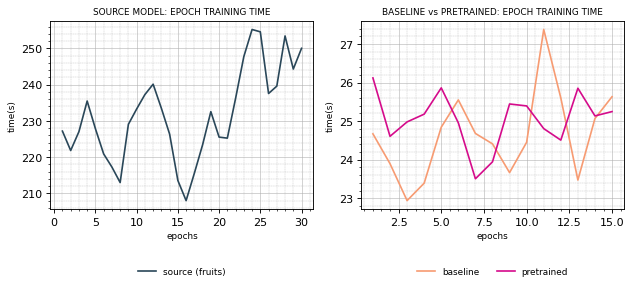

In [70]:
epochs_source = np.arange(1, len(fruits_history.epoch_train_time) + 1)
epochs_target = np.arange(1, len(baseline_history.epoch_train_time) + 1)
source_history = fruits_history
pretrained_history = weighted_history
fig, axes = plt.subplots(1, 2, figsize=(8, 4), dpi=80)

axes[0].plot(epochs_source, source_history.epoch_train_time,
             label="source (fruits)", color=PALETTES.retro[10])

axes[0].set_title("SOURCE MODEL: EPOCH TRAINING TIME", fontsize=8)
axes[0].set_xlabel("epochs", fontsize=8)
axes[0].set_ylabel("time(s)", fontsize=8)

axes[0].minorticks_on()
axes[0].grid(which='major', linestyle='-', linewidth=0.5)
axes[0].grid(which='minor', linestyle='--', linewidth=0.3)
axes[0].legend(ncol=3, frameon=False, fontsize=8, title="",
    bbox_to_anchor=(0.5, -.4), loc="lower center",)

axes[1].plot(epochs_target, baseline_history.epoch_train_time,
             label="baseline", color=PALETTES.retro[11])

axes[1].plot(epochs_target, pretrained_history.epoch_train_time,
             label="pretrained", color=PALETTES.retro[12])

axes[1].set_title("BASELINE vs PRETRAINED: EPOCH TRAINING TIME", fontsize=8)
axes[1].set_xlabel("epochs", fontsize=8)
axes[1].set_ylabel("time(s)", fontsize=8)

axes[1].minorticks_on()
axes[1].grid(which='major', linestyle='-', linewidth=0.5)
axes[1].grid(which='minor', linestyle='--', linewidth=0.3)

axes[1].legend(ncol=3, frameon=False, fontsize=8, title="",
    bbox_to_anchor=(0.5, -.4), loc="lower center")

plt.tight_layout()
plt.show()

### 📈 Validation and Training Accuracies

In the following code cell, we will **visualize the training and validation accuracies per epoch** using line graphs for all models.  

This includes:
- The **source model** (trained on the Fruits and Vegetables dataset)  
- The **baseline model** (trained from scratch on the Banana Ripeness dataset)  
- The **pretrained model** (fine-tuned using transferred weights)  

These visualizations provide insight into how each model **learns over time**, allowing us to monitor **performance improvements**, compare learning behavior, and detect potential **overfitting or underfitting**.

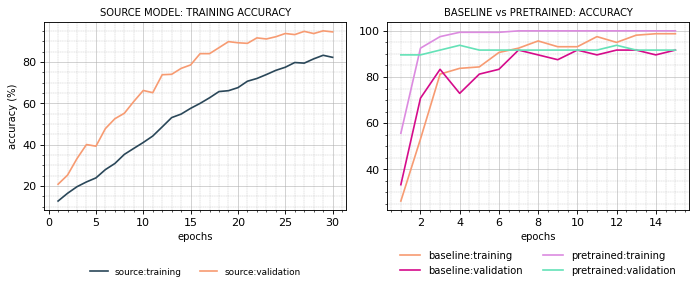

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4), dpi=80)
axes[0].plot(epochs_source,
             [i * 100 for i in source_history.train_acc],
             label="source:training", color=PALETTES.retro[10])
axes[0].plot(epochs_source,
             [i * 100 for i in source_history.val_acc],
             label="source:validation", color=PALETTES.retro[11])

axes[0].set_title("SOURCE MODEL: TRAINING ACCURACY", fontsize=9)
axes[0].set_xlabel("epochs", fontsize=9)
axes[0].set_ylabel("accuracy (%)", fontsize=9)

axes[0].minorticks_on()
axes[0].grid(which='major', linestyle='-', linewidth=0.5)
axes[0].grid(which='minor', linestyle='--', linewidth=0.3)

axes[0].legend(ncol=2, loc="lower center", frameon=False, fontsize=8, title="",
    bbox_to_anchor=(0.5, -.4))


axes[1].plot(epochs_target,
             [i * 100 for i in baseline_history.train_acc],
             label="baseline:training", color=PALETTES.retro[11])

axes[1].plot(epochs_target,
             [i * 100 for i in baseline_history.val_acc],
             label="baseline:validation", color=PALETTES.retro[12])

axes[1].plot(epochs_target,
             [i * 100 for i in pretrained_history.train_acc],
             label="pretrained:training", color=PALETTES.retro[13])

axes[1].plot(epochs_target,
             [i * 100 for i in pretrained_history.val_acc],
             label="pretrained:validation", color=PALETTES.retro[14])

axes[1].set_title("BASELINE vs PRETRAINED: ACCURACY", fontsize=9)
axes[1].set_xlabel("epochs", fontsize=9)
axes[1].set_ylabel("", fontsize=9)

axes[1].minorticks_on()
axes[1].grid(which='major', linestyle='-', linewidth=0.5)
axes[1].grid(which='minor', linestyle='--', linewidth=0.3)

axes[1].legend(loc="lower center",
               ncol=2, frameon=False, fontsize=9,
               bbox_to_anchor=(0.5, -0.4))
plt.tight_layout()
plt.show()

### 📉 Validation and Training Losses

In the following code cell, we will **visualize the training and validation losses per epoch** using line graphs for all models.  

This includes:
- The **source model** (trained on the Fruits and Vegetables dataset)  
- The **baseline model** (trained from scratch on the Banana Ripeness dataset)  
- The **pretrained model** (fine-tuned using transferred weights)  

These plots help track the model’s **learning progress over time**, enabling us to identify patterns such as **overfitting**, **underfitting**, and convergence behavior across different training strategies.

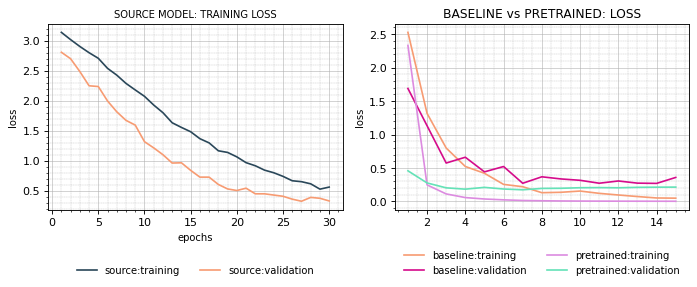

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4), dpi=80)
axes[0].plot(epochs_source,
             source_history.train_losses,
             label="source:training", color=PALETTES.retro[10])

axes[0].plot(epochs_source,
             source_history.val_losses,
             label="source:validation", color=PALETTES.retro[11])

axes[0].set_title("SOURCE MODEL: TRAINING LOSS", fontsize=9)
axes[0].set_xlabel("epochs", fontsize=9)
axes[0].set_ylabel("loss", fontsize=9)

axes[0].minorticks_on()
axes[0].grid(which='major', linestyle='-', linewidth=0.5)
axes[0].grid(which='minor', linestyle='--', linewidth=0.3)

axes[0].legend(loc="lower center",  ncol=2, frameon=False, fontsize=9,
               bbox_to_anchor=(0.5, -0.4))

axes[1].plot(epochs_target,
             baseline_history.train_losses,
             label="baseline:training", color=PALETTES.retro[11])

axes[1].plot(epochs_target,
             baseline_history.val_losses,
             label="baseline:validation", color=PALETTES.retro[12])

axes[1].plot(epochs_target,
             pretrained_history.train_losses,
             label="pretrained:training", color=PALETTES.retro[13])

axes[1].plot(epochs_target,
             pretrained_history.val_losses,
             label="pretrained:validation", color=PALETTES.retro[14])

axes[1].set_title("BASELINE vs PRETRAINED: LOSS", fontsize=11)
axes[1].set_xlabel("", fontsize=9)
axes[1].set_ylabel("loss", fontsize=9)

axes[1].minorticks_on()
axes[1].grid(which='major', linestyle='-', linewidth=0.5)
axes[1].grid(which='minor', linestyle='--', linewidth=0.3)

axes[1].legend(loc="lower center", ncol=2, frameon=False, fontsize=9,
               bbox_to_anchor=(0.5, -0.4))

plt.tight_layout()
plt.show()

### 🧪 Best Model Evaluation

In the following code cell, we will **define a function to evaluate the best-performing model** (based on validation performance during training).  

This function will compute both the **loss** and **accuracy** on the **test dataset**, providing a clear assessment of how well the model **generalizes to unseen data**.  

The evaluation will be applied to the selected best model from our experiments, enabling a fair comparison of final performance.

In [75]:
def evaluate_best_model(model, model_name, test_iterator, criterion, device):
  model.load_state_dict(torch.load(model_name, weights_only=True))
  test_loss, test_acc = evaluate(model, test_iterator, criterion, device)
  return f'{test_loss:.2f}', f'{test_acc * 100:.2f}'


tabulate_data(
    ["NAME", "LOSS", "ACCURACY (%)"],
    [
        ['fruits', *evaluate_best_model(fruits_lenet, 'fruits.pt', fruits_test_iterator, criterions['fruits'], device)],
        ['baseline', *evaluate_best_model(baseline_banana_lenet, 'baseline.pt', banana_test_iterator, criterions['baseline'], device)],
        ['weighted', *evaluate_best_model(weighted_banana_lenet, 'weighted.pt', banana_test_iterator, criterions['weighted'], device)],
    ],
    "BEST MODEL'S LOSS AND ACCURACY"
)

BEST MODEL'S LOSS AND ACCURACY
+----------+------+--------------+
| NAME     | LOSS | ACCURACY (%) |
+----------+------+--------------+
| fruits   | 0.35 |        94.46 |
| baseline | 0.09 |        96.15 |
| weighted | 0.05 |        98.08 |
+----------+------+--------------+


### 📊 Model Evaluation Metrics

In this section, we will **evaluate the performance of the compared models**—the **baseline** and **pretrained (transfer learning)** models—using key evaluation metrics.

For this multi-class classification task, we will use:

1. **Confusion Matrix** – to analyze how well each class is predicted.  
2. **Classification Report** – to obtain **precision, recall, F1-score, and support** for each class.  

The first step is to **generate predictions on the test dataset** for both models. These predictions will then be used to compute and compare the evaluation metrics, providing a clear understanding of how transfer learning impacts performance.

In [76]:
def get_predictions(model, iterator, device):
  model.eval()
  images = []
  labels = []
  probs = []
  with torch.no_grad():
    for (x, y) in iterator:
      x = x.to(device)
      y_pred = model(x)
      y_prob = F.softmax(y_pred, dim = -1)
      top_pred = y_prob.argmax(1, keepdim = True)
      images.append(x.cpu())
      labels.append(y.cpu())
      probs.append(y_prob.cpu())
  images = torch.cat(images, dim = 0)
  labels = torch.cat(labels, dim = 0)
  probs = torch.cat(probs, dim = 0)
  return images, labels, probs

baseline_test_images, baseline_test_labels, baseline_probs = get_predictions(baseline_banana_lenet, banana_test_iterator, device)
weighted_test_images, weighted_test_labels, weighted_probs = get_predictions(weighted_banana_lenet, banana_test_iterator, device)

Next we are going to convert our predictions from probabilities to real labels.

In [77]:
weighted_preds = torch.argmax(weighted_probs, 1).numpy().astype(np.int32)
weighted_test_labels = weighted_test_labels.numpy()

baseline_preds = torch.argmax(baseline_probs, 1).numpy().astype(np.int32)
baseline_test_labels = baseline_test_labels.numpy()

### 🖼️ Plotting Predictions

In this section, we will **visualize the predictions of the compared models**—the **baseline** and **pretrained (transfer learning)** models—on sample images from the *Banana Ripeness dataset*.  

This qualitative analysis helps us understand how each model behaves in practice, highlighting **correct predictions**, **misclassifications**, and overall differences in performance between the two approaches.

In [78]:
def get_predictions_labels(test_images, preds, test_labels):
    test_images_labels = list(zip(test_images, preds, test_labels))
    random.shuffle(test_images_labels)
    y_true = []
    y_pred = []
    images = []
    
    for img, pred, label in test_images_labels[:24]:
      y_true.append(label)
      y_pred.append(pred)
      images.append(img)
    
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return images, y_true, y_pred


weighted_images, weighted_y_true, weighted_y_pred = get_predictions_labels(weighted_test_images, weighted_preds, weighted_test_labels)
baseline_images, baseline_y_true, baseline_y_pred = get_predictions_labels(baseline_test_images, baseline_preds, baseline_test_labels)

Next we are going to define the function that will plot the predictions for us.

In [81]:
def plot_predictions_images(images_and_classes,
                            labels_true, labels_pred,
                            cols=5):
    rows = 3
    fig = plt.figure()
    fig.set_size_inches(cols * 2, rows * 2)
    for i, (image, label_true, label_pred) in enumerate(zip(images_and_classes, labels_true.astype("int32"), labels_pred)):
        plt.subplot(rows, cols, i + 1)
        plt.axis('off')
        image = normalize_image(image)
        plt.imshow(image.permute(1, 2, 0).cpu().numpy(), cmap="gray")
        plt.title(banana_class_names[label_pred], color ='g' if label_true == label_pred else 'r', fontsize=10 )

Next, we will **plot the predictions made by the baseline and pretrained `LeNet` models**.  

This visualization allows us to **assess how accurately each model classifies sample images** and provides a direct **qualitative comparison** between the **baseline (trained from scratch)** and the **pretrained (transfer learning)** approaches.

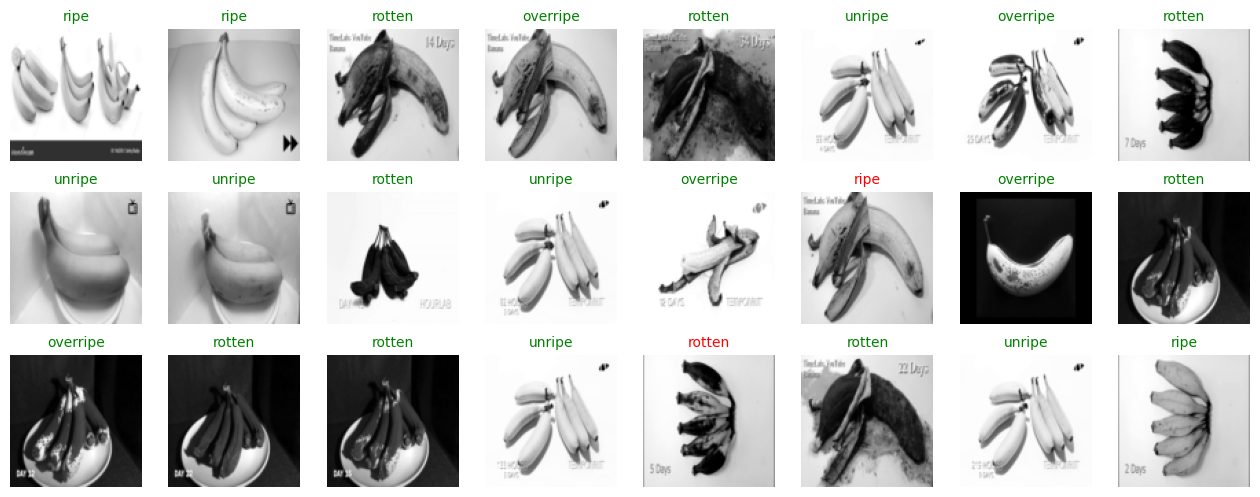

In [82]:
plot_predictions_images(weighted_images[:24], weighted_y_true[:24], weighted_y_pred[:24], cols=8)

Next, we will **plot the predictions made by the `LeNet` models**—both the **baseline** and **pretrained (transfer learning)** versions.  

This visualization allows us to **assess how accurately each model classifies sample images** and provides a clear **qualitative comparison** between the two approaches, highlighting differences in prediction performance.

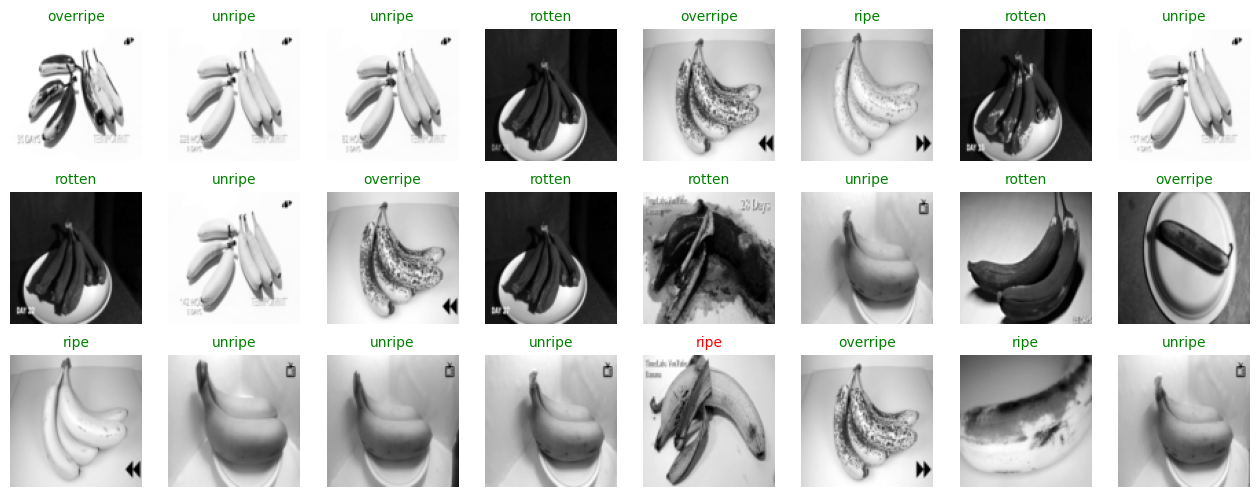

In [83]:
plot_predictions_images(baseline_images[:24], baseline_y_true[:24], baseline_y_pred[:24], cols=8)

### 📊 Confusion Matrix

In the following code cell, we will **visualize the confusion matrices** for the **baseline** and **pretrained (transfer learning)** models using the **test dataset**.  

The confusion matrix provides a detailed view of how well each model predicts every class, highlighting **correct classifications** and **misclassifications**. This allows for a clear comparison of performance across classes and between the two models.

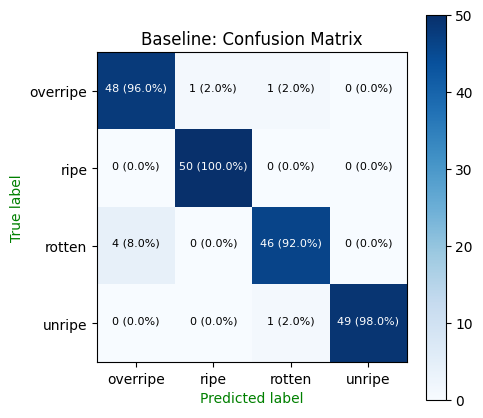

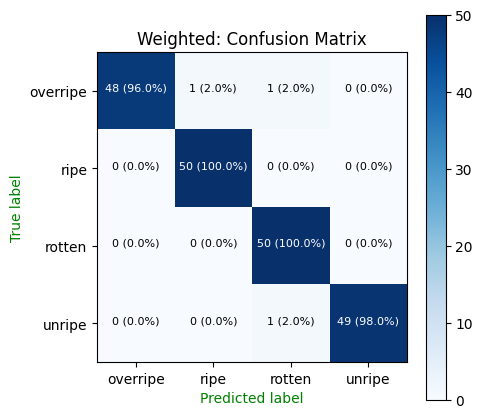

In [85]:
plot_complicated_confusion_matrix(baseline_test_labels, baseline_preds, banana_class_names,
                                  fontsize=8, figsize=(5, 5), title="Baseline: Confusion Matrix")
plot_complicated_confusion_matrix(weighted_test_labels, weighted_preds, banana_class_names,
                                  fontsize=8, figsize=(5, 5), title="Weighted: Confusion Matrix")

### 📄 Classification Report

In the following code cell, we will **print the classification reports** for the **baseline** and **pretrained (transfer learning)** models using the **test dataset**.  

These reports include **precision, recall, F1-score, and support** for each class, providing a comprehensive evaluation of model performance. This allows for a detailed **comparison between the two models** across all classes.

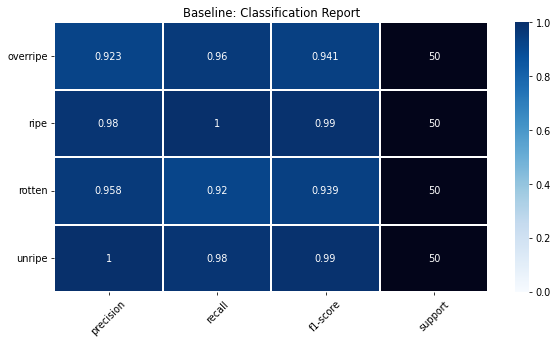

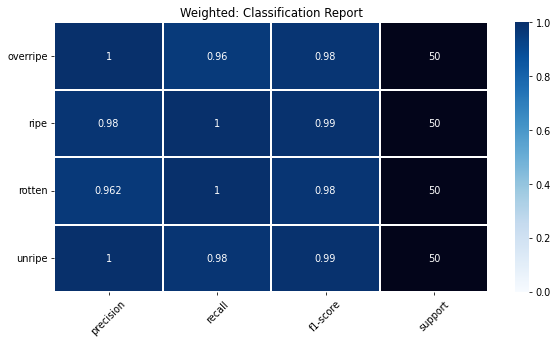

In [86]:
fig, ax = visualization.plot_classification_report(baseline_test_labels, baseline_preds,
                    title='Baseline: Classification Report',
                    figsize=(10, 5), dpi=70,
                    target_names = banana_class_names
)

fig, ax = visualization.plot_classification_report(weighted_test_labels, weighted_preds,
                    title='Weighted: Classification Report',
                    figsize=(10, 5), dpi=70,
                    target_names = banana_class_names
)

### ❌ Misclassified Samples

In this section, we will **visualize the misclassified images**, if any exist, from the *Banana Ripeness dataset*.  

This analysis helps us **understand the errors made by the models**—both the **baseline** and **pretrained (transfer learning)** models—and identify which ripeness stages are more challenging to classify correctly. It also provides insight into potential areas for improvement.

In [87]:
weighted_corrects = torch.eq(torch.from_numpy(weighted_test_labels), torch.from_numpy(weighted_preds))
baseline_corrects = torch.eq(torch.from_numpy(baseline_test_labels), torch.from_numpy(baseline_preds))

In [89]:
def get_incorrect_examples(images, labels, probabilities, corrects):
  incorrect_examples = []
  for image, label, prob, correct in zip(images, labels, probabilities, corrects):
    if not correct:
      incorrect_examples.append((image, label, prob))
  return incorrect_examples

baseline_incorrect_examples = get_incorrect_examples(baseline_test_images, baseline_test_labels, baseline_probs, baseline_corrects)
weighted_incorrect_examples = get_incorrect_examples(weighted_test_images, weighted_test_labels, weighted_probs, weighted_corrects)

In [90]:
def plot_most_incorrect(incorrect, classes, n_images, normalize = True):
  rows = int(np.sqrt(n_images))
  cols = int(np.sqrt(n_images))
  fig = plt.figure(figsize = (6, 4))
  for i in range(rows*cols):
    ax = fig.add_subplot(rows, cols, i+1)
    image, true_label, probs = incorrect[i]
    image = image.permute(1, 2, 0)
    true_class = classes[true_label]
    incorrect_class = classes[0 if true_label == 1 else 1]
    if normalize:
      image = normalize_image(image)
    ax.imshow(image.cpu().numpy(), cmap="gray")
    ax.set_title(f'real: {true_class}\n' \
                  f'predicted: {incorrect_class}', fontsize=8)
    ax.axis('off')
  fig.subplots_adjust(hspace=0.4)

In the following code cell, we will **plot the most misclassified images** from the *Banana Ripeness dataset*.  

This visualization highlights the samples that the **baseline** and **pretrained (transfer learning)** models struggle with the most, providing deeper insight into **common error patterns** and challenging classes.

No incorrectly Predicted Images


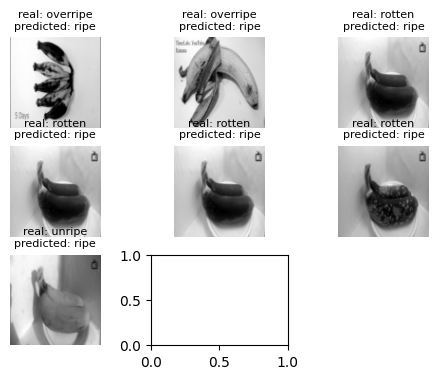

In [91]:
N_IMAGES = 12
try:
    plot_most_incorrect(baseline_incorrect_examples, banana_class_names, N_IMAGES)
except:
    print("No incorrectly Predicted Images")

No incorrectly Predicted Images


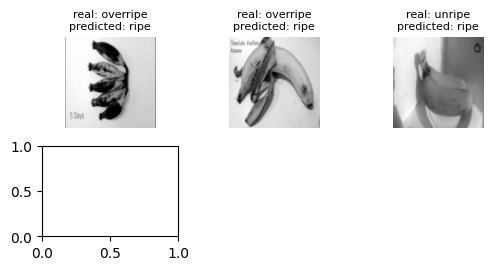

In [92]:
N_IMAGES = 12
try:
    plot_most_incorrect(weighted_incorrect_examples, banana_class_names, N_IMAGES)
except:
    print("No incorrectly Predicted Images")

### Model sizes

In the following code cell we are going to calculate the model size for each model. This will help us to understand the disk requirements of each model.

In [96]:
def model_size(path: str):
    num = os.path.getsize(path)
    for unit in ['bytes', 'KB', 'MB', 'GB', 'TB']:
        if num < 1024.0:
            return f"{num:.1f} {unit}"
        num /= 1024.0

tabulate_data(
    ["Model", "Size"],
    [
        ['fruits', model_size('fruits.pt')],
        ['baseline',  model_size('baseline.pt')],
        ['weighted',  model_size('weighted.pt')],
    ],
    "BEST MODEL'S DISC SIZE"
)

BEST MODEL'S DISC SIZE
+----------+--------+
| Model    |   Size |
+----------+--------+
| fruits   | 3.5 MB |
| baseline | 3.5 MB |
| weighted | 3.5 MB |
+----------+--------+
